In [26]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputClassifier



from imblearn.over_sampling import SMOTE
import joblib

In [27]:
#Load the dataset
df = pd.read_csv('../dataset/ai4i2020.csv')

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Dataset Shape: (10000, 14)

Columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [28]:
#Basic EDA
print(df.dtypes)
print(df.describe())

print("\nMachine Failure Distribution:")
print(df['Machine failure'].value_counts())
print(f"Failure Rate: {df['Machine failure'].mean()*100:.2f}%")


UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object
               UDI  Air temperature [K]  Process temperature [K]  \
count  10000.00000         10000.000000             10000.000000   
mean    5000.50000           300.004930               310.005560   
std     2886.89568             2.000259                 1.483734   
min        1.00000           295.300000               305.700000   
25%     2500.75000           298.300000               308.800000   
50%     5000.50000           300.100000               310.100000   
75%     7500.25000  

In [29]:
#Remove Unnecessary Columns
columns_to_remove = ['UDI', 'Product ID']
df = df.drop(columns=columns_to_remove)

print("Shape after removal:", df.shape)

Shape after removal: (10000, 12)


In [30]:
#Data preprocessing
df_new = df.copy()

# Check missing values
print(df_new.isnull().sum())

# One-hot encoding
df_new = pd.get_dummies(df_new, columns=['Type'], drop_first=True)

df_new.head()

Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,False,True
1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,True,False
2,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,True,False
3,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,True,False
4,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,True,False


In [31]:
#Split features & Target
target_columns = ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

X = df_new.drop(columns=target_columns)
y = df_new[target_columns]

In [22]:
#Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# # SMOTE (only on training data)
# smote = SMOTE(random_state=42)
# X_train, y_train = smote.fit_resample(X_train, y_train)

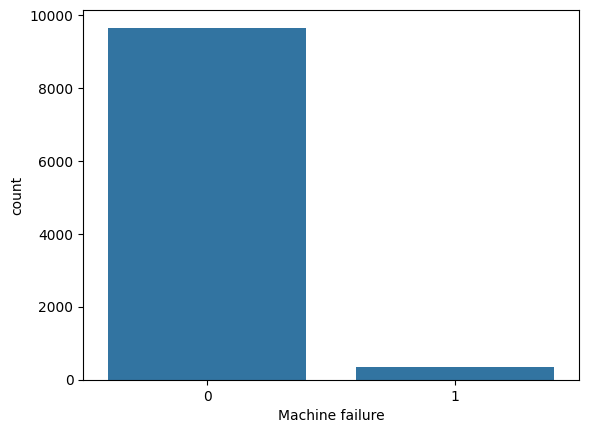

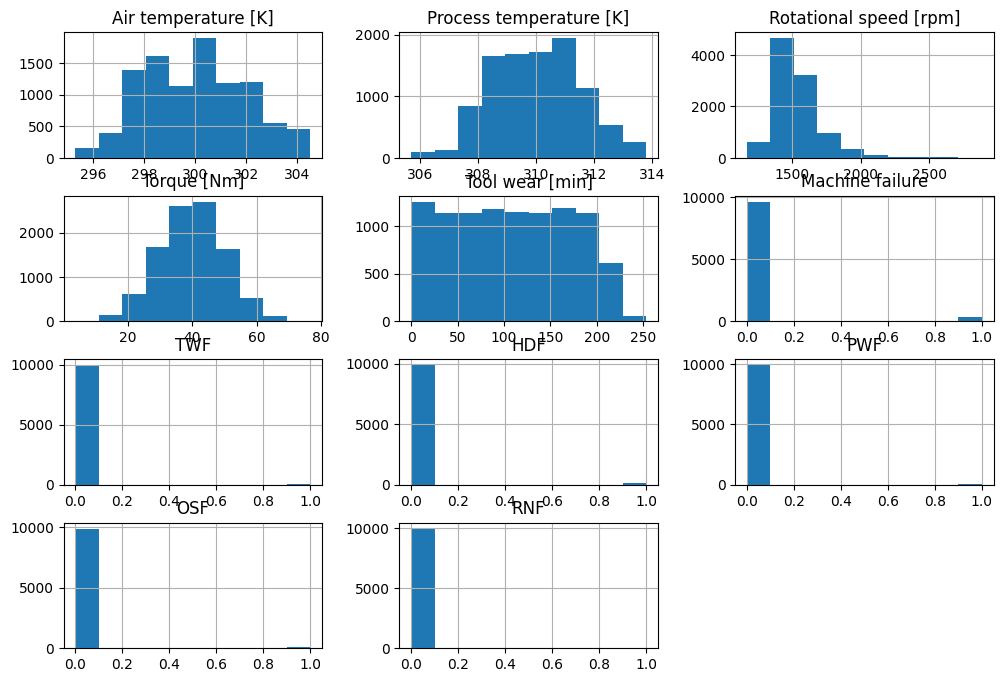

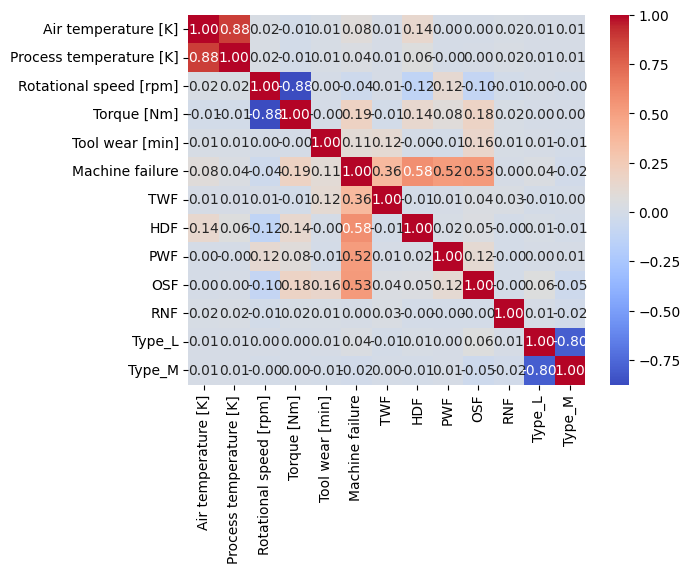

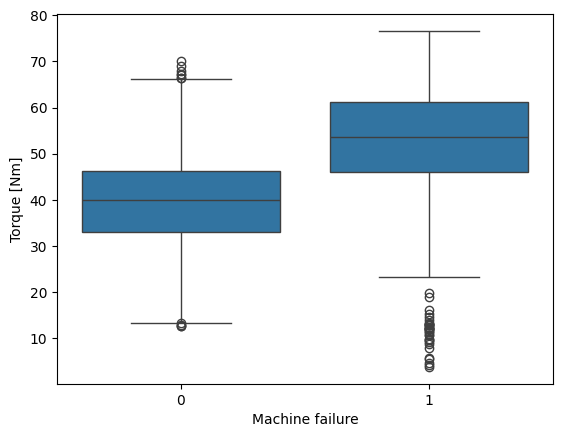

In [33]:
#EDA visualization
sns.countplot(x='Machine failure', data=df_new)
plt.show()

df.hist(figsize=(12,8))
plt.show()

sns.heatmap(df_new.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

sns.boxplot(x='Machine failure', y='Torque [Nm]', data=df_new)
plt.show()

In [37]:
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

log_model = MultiOutputClassifier(
    LogisticRegression(max_iter=1000)
)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

target_columns = ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

for i, target in enumerate(target_columns):
    print(f"\n===== {target} =====")
    print(confusion_matrix(y_test.iloc[:, i], y_pred_log[:, i]))
    print(classification_report(y_test.iloc[:, i], y_pred_log[:, i]))


===== Machine failure =====
[[1931    8]
 [  45   16]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1939
           1       0.67      0.26      0.38        61

    accuracy                           0.97      2000
   macro avg       0.82      0.63      0.68      2000
weighted avg       0.97      0.97      0.97      2000


===== TWF =====
[[1989    0]
 [  11    0]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1989
           1       0.00      0.00      0.00        11

    accuracy                           0.99      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.99      0.99      0.99      2000


===== HDF =====
[[1982    1]
 [  12    5]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1983
           1       0.83      0.29      0.43        17

    accuracy                          

c:\Users\Wadhwa's\OneDrive\Desktop\Car-Health-Predictions\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Wadhwa's\OneDrive\Desktop\Car-Health-Predictions\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Wadhwa's\OneDrive\Desktop\Car-Health-Predictions\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

In [43]:
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier

base_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)

rf_model = MultiOutputClassifier(base_model)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

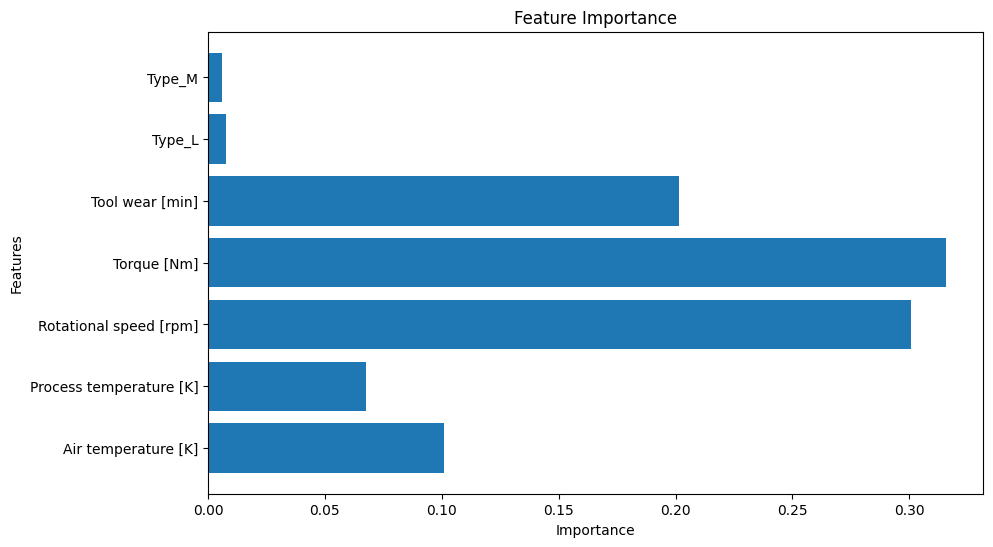

In [45]:
import matplotlib.pyplot as plt

feature_importance = rf_model.estimators_[0].feature_importances_

feature_names = X.columns

plt.figure(figsize=(10,6))
plt.barh(feature_names, feature_importance)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance")
plt.show()

In [44]:
from sklearn.metrics import confusion_matrix, classification_report

for i, target in enumerate(target_columns):
    print(f"\n===== {target} =====")
    print(confusion_matrix(y_test.iloc[:, i], y_pred_rf[:, i]))
    print(classification_report(y_test.iloc[:, i], y_pred_rf[:, i], zero_division=0))


===== Machine failure =====
[[1922   17]
 [  28   33]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1939
           1       0.66      0.54      0.59        61

    accuracy                           0.98      2000
   macro avg       0.82      0.77      0.79      2000
weighted avg       0.98      0.98      0.98      2000


===== TWF =====
[[1984    5]
 [   9    2]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1989
           1       0.29      0.18      0.22        11

    accuracy                           0.99      2000
   macro avg       0.64      0.59      0.61      2000
weighted avg       0.99      0.99      0.99      2000


===== HDF =====
[[1972   11]
 [   5   12]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1983
           1       0.52      0.71      0.60        17

    accuracy                          

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputClassifier



from imblearn.over_sampling import SMOTE
import joblib

In [ ]:
#Load the dataset
df = pd.read_csv('../dataset/ai4i2020.csv')

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Dataset Shape: (10000, 14)

Columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [ ]:
#Basic EDA
print(df.dtypes)
print(df.describe())

print("\nMachine Failure Distribution:")
print(df['Machine failure'].value_counts())
print(f"Failure Rate: {df['Machine failure'].mean()*100:.2f}%")


UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object
               UDI  Air temperature [K]  Process temperature [K]  \
count  10000.00000         10000.000000             10000.000000   
mean    5000.50000           300.004930               310.005560   
std     2886.89568             2.000259                 1.483734   
min        1.00000           295.300000               305.700000   
25%     2500.75000           298.300000               308.800000   
50%     5000.50000           300.100000               310.100000   
75%     7500.25000  

In [ ]:
#Remove Unnecessary Columns
columns_to_remove = ['UDI', 'Product ID']
df = df.drop(columns=columns_to_remove)

print("Shape after removal:", df.shape)

Shape after removal: (10000, 12)


In [ ]:
#Data preprocessing
df_new = df.copy()

# Check missing values
print(df_new.isnull().sum())

# One-hot encoding
df_new = pd.get_dummies(df_new, columns=['Type'], drop_first=True)

df_new.head()

Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,False,True
1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,True,False
2,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,True,False
3,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,True,False
4,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,True,False


In [ ]:
#Split features & Target
target_columns = ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

X = df_new.drop(columns=target_columns)
y = df_new[target_columns]

In [ ]:
#Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [48]:
# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# # SMOTE (only on training data)
# smote = SMOTE(random_state=42)
# X_train, y_train = smote.fit_resample(X_train, y_train)

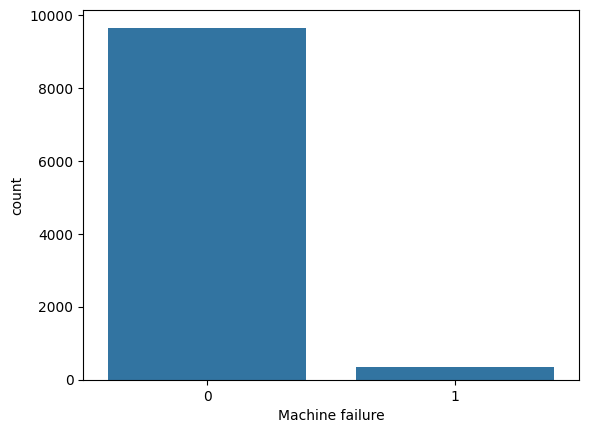

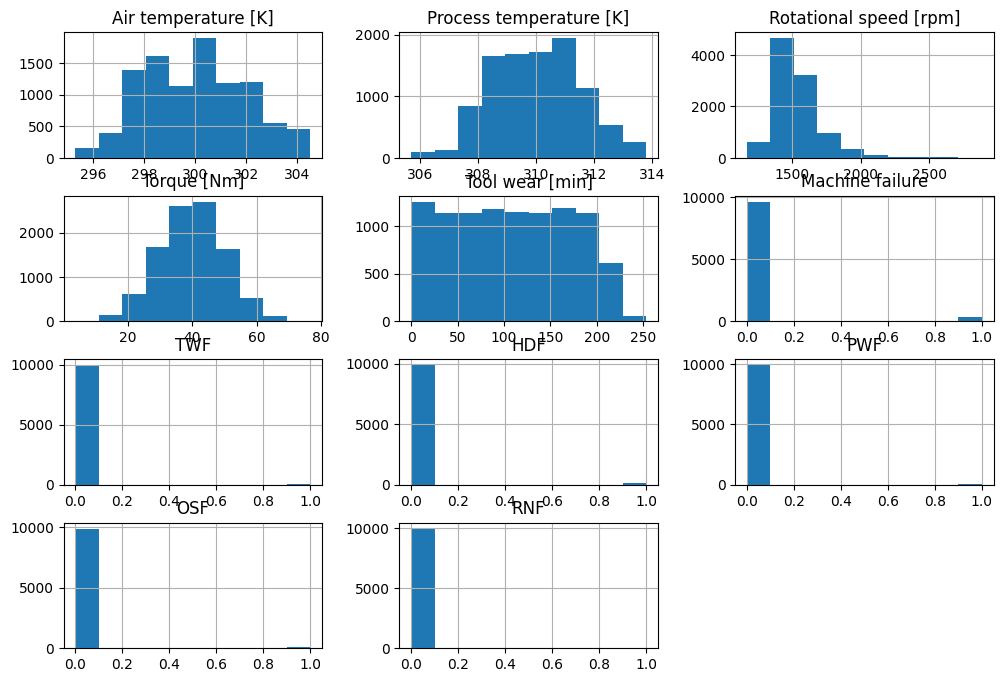

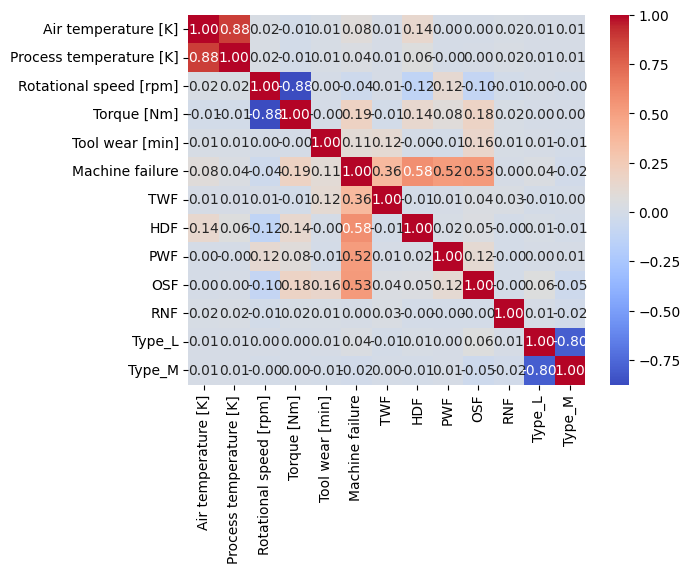

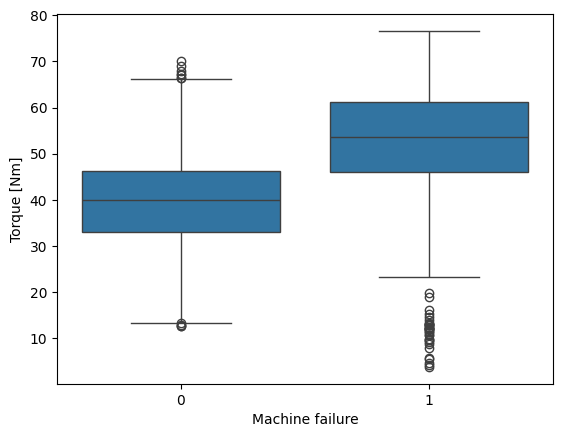

In [ ]:
#EDA visualization
sns.countplot(x='Machine failure', data=df_new)
plt.show()

df.hist(figsize=(12,8))
plt.show()

sns.heatmap(df_new.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

sns.boxplot(x='Machine failure', y='Torque [Nm]', data=df_new)
plt.show()

In [ ]:
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

log_model = MultiOutputClassifier(
    LogisticRegression(max_iter=1000)
)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

target_columns = ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

for i, target in enumerate(target_columns):
    print(f"\n===== {target} =====")
    print(confusion_matrix(y_test.iloc[:, i], y_pred_log[:, i]))
    print(classification_report(y_test.iloc[:, i], y_pred_log[:, i]))


===== Machine failure =====
[[1931    8]
 [  45   16]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1939
           1       0.67      0.26      0.38        61

    accuracy                           0.97      2000
   macro avg       0.82      0.63      0.68      2000
weighted avg       0.97      0.97      0.97      2000


===== TWF =====
[[1989    0]
 [  11    0]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1989
           1       0.00      0.00      0.00        11

    accuracy                           0.99      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.99      0.99      0.99      2000


===== HDF =====
[[1982    1]
 [  12    5]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1983
           1       0.83      0.29      0.43        17

    accuracy                          

c:\Users\Wadhwa's\OneDrive\Desktop\Car-Health-Predictions\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Wadhwa's\OneDrive\Desktop\Car-Health-Predictions\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Wadhwa's\OneDrive\Desktop\Car-Health-Predictions\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

In [ ]:
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier

base_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)

rf_model = MultiOutputClassifier(base_model)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [49]:
# Evaluation for each target
target_columns = ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

for i, target in enumerate(target_columns):

    print(f"\n==============================")
    print(f"TARGET: {target}")
    print(f"==============================")

    # Confusion Matrix
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test.iloc[:, i], y_pred_rf[:, i]))

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test.iloc[:, i], y_pred_rf[:, i]))


TARGET: Machine failure

Confusion Matrix:
[[1922   17]
 [  28   33]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1939
           1       0.66      0.54      0.59        61

    accuracy                           0.98      2000
   macro avg       0.82      0.77      0.79      2000
weighted avg       0.98      0.98      0.98      2000


TARGET: TWF

Confusion Matrix:
[[1984    5]
 [   9    2]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1989
           1       0.29      0.18      0.22        11

    accuracy                           0.99      2000
   macro avg       0.64      0.59      0.61      2000
weighted avg       0.99      0.99      0.99      2000


TARGET: HDF

Confusion Matrix:
[[1972   11]
 [   5   12]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0

c:\Users\Wadhwa's\OneDrive\Desktop\Car-Health-Predictions\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Wadhwa's\OneDrive\Desktop\Car-Health-Predictions\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Wadhwa's\OneDrive\Desktop\Car-Health-Predictions\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

In [51]:
#Save Model & Scalar
joblib.dump(rf_model, "../saved_models/model.pkl")
joblib.dump(scaler, "../saved_models/scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [52]:
#Save Model & Scalar
joblib.dump(rf_model, "../saved_models/model.pkl")
joblib.dump(scaler, "../saved_models/scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
